# Plasmadiagnostik mit Langmuir-Sonden

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
from scipy.optimize import least_squares
import os

In [19]:
def logistic_res(coeff, x, y):
    a, b, c, d, e = coeff
    return y - (a/(1+np.exp(-b*(x-c)))+d*x+e)

def logistic(coeff, x):
    a, b, c, d, e = coeff
    return a/(1+np.exp(-b*(x-c)))+d*x+e

def derive(x, y, step=1):
    x, y = list(x), list(y)
    x_new, y_new = [], []
    for i, val in enumerate(x):
        if i%step == 0:
            x_new.append(val)
    for i, val in enumerate(y):
        if i % step == 0:
            y_new.append(val)
    x_new = np.array(x_new)
    y_new = np.array(y_new)
    der = np.insert(np.diff(y_new)/np.diff(x_new), 0, np.nan)
    return x_new, der

## Bestimmen des Plasmapotentials für alle (Sonden-) Kennlinien

Mögliche Methoden zur Bestimmung:
 1. Wendepunkt der Kennlinie: Maximum von $\frac{\mathrm{d}I_e(U)}{\mathrm{d}U}$
 2. Schnittpunkt der Geraden im $\ln (I_e)$ gegen $U$ plot

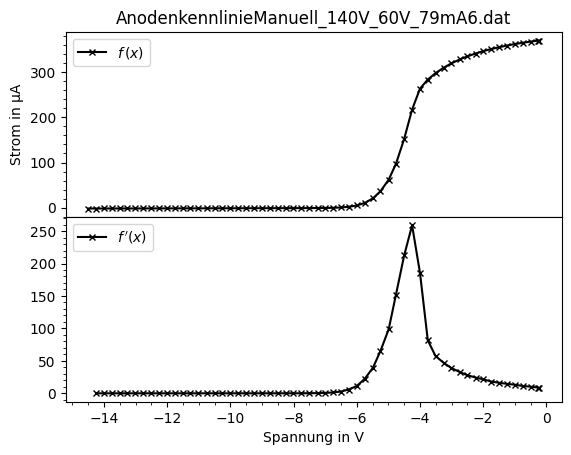

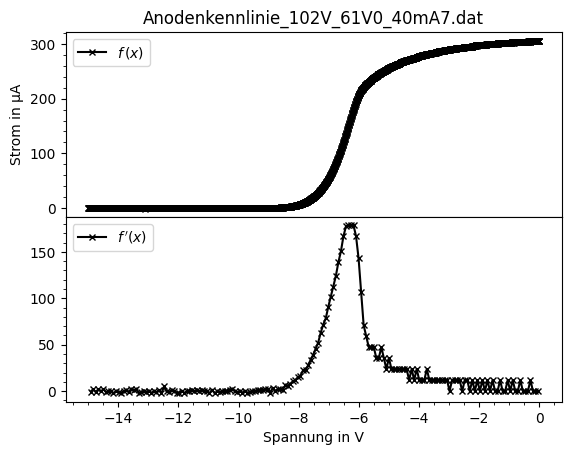

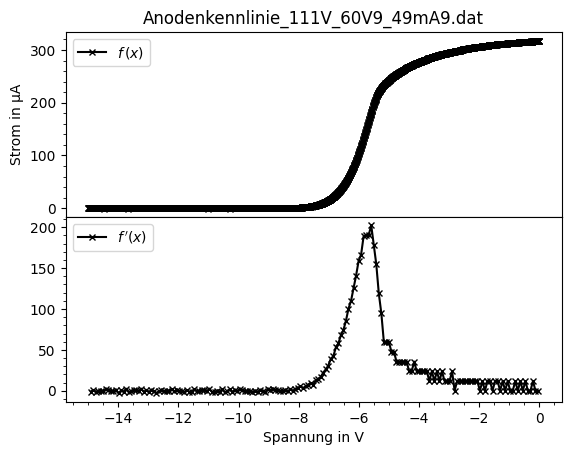

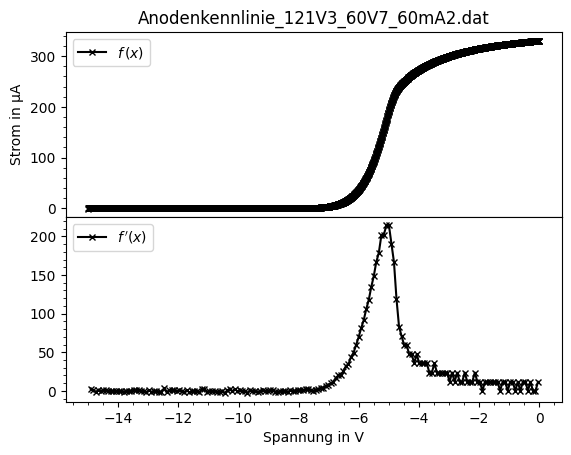

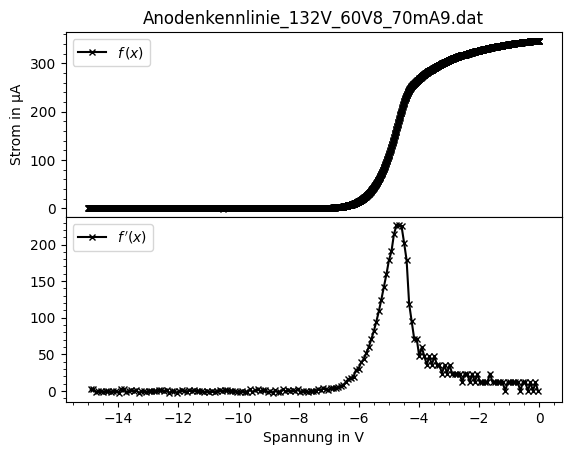

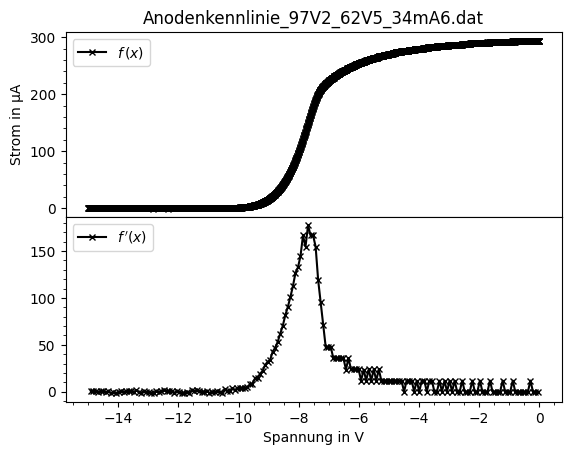

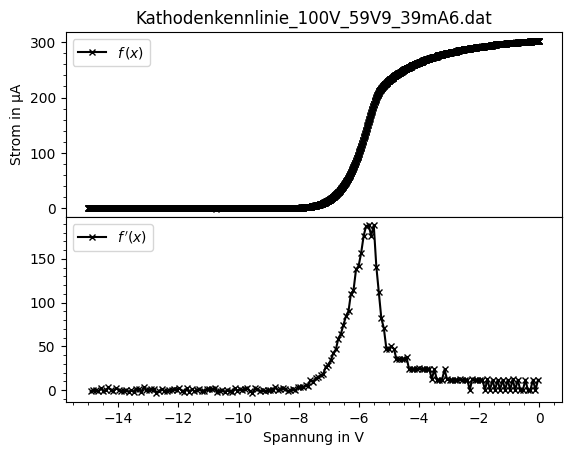

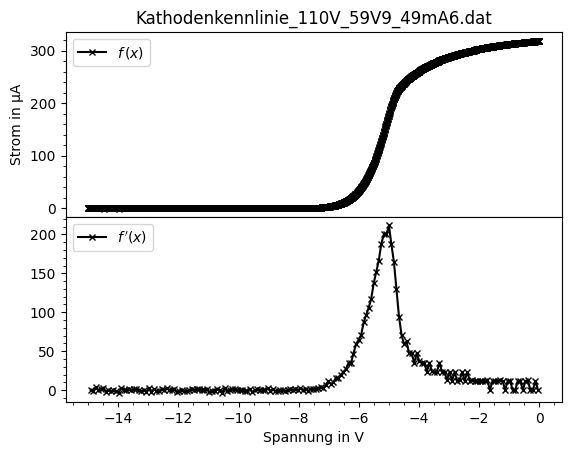

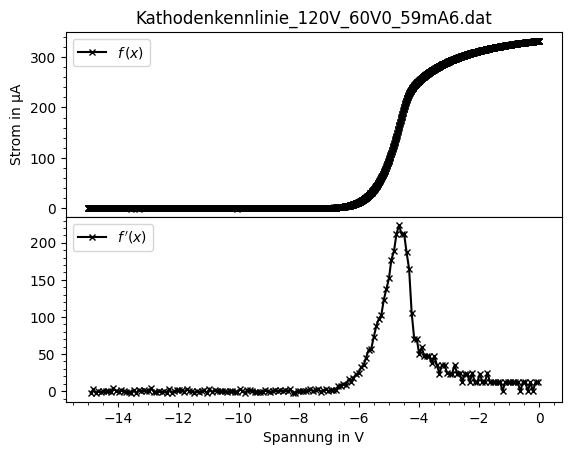

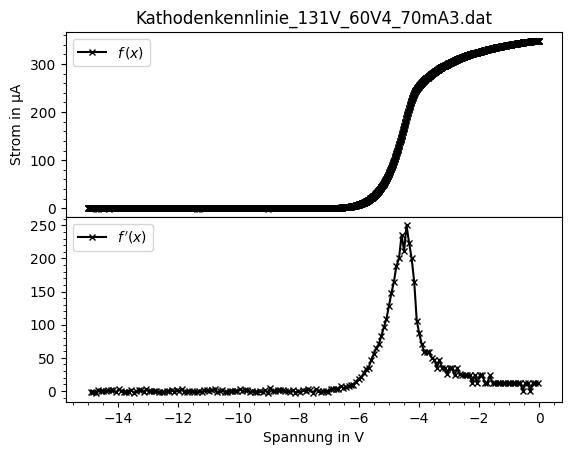

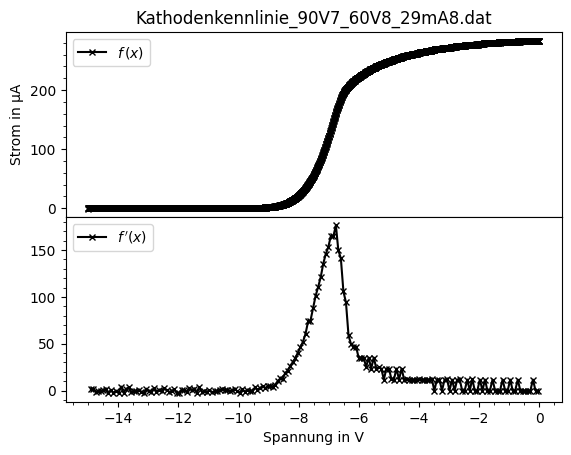

In [41]:
# Methode 1

for file in os.listdir(r'../Messdaten/17112025_Langmuirsonden/'):
    if file[-2] == 'x':
        pass
    elif len(file.split('_')) == 4: # Nur Anoden und Kathodenkennlinie ohne HHS
        data = np.loadtxt(f'../Messdaten/17112025_Langmuirsonden/{file}', delimiter = '\t', skiprows=3)
        U = data[:,0]
        I = data[:,1]*1e6 # in µA
        if file.split('_')[0] == 'Kathodenkennlinie':
            U = U - max(U)
        # Ableiten der Kennlinie funktioniert für die automatischen nur mit größeren Steigungsdreiecken
        if file.split('_')[0] == 'AnodenkennlinieManuell':
            dU = U
            dIdU = np.insert(np.diff(I)/np.diff(U), 0, np.nan)
        else:
            dU, dIdU = derive(U, I, step=14)
        # plotten
        fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, gridspec_kw={'hspace':0.0}) #layout='constrained')
        ax1.plot(U, I, 'x-k', ms=4, label=r'$f\,(x)$')
        ax2.plot(dU, dIdU, 'x-k', ms=4, label=r"$f\,^\prime (x)$")
        ax2.set_xlabel('Spannung in V')
        ax1.set_ylabel('Strom in µA')
        ax1.set_title(file)
        ax1.legend(loc=2)
        ax2.legend(loc=2)
        ax1.minorticks_on()
        ax2.minorticks_on()
        plt.show()